In [2]:
pip install emcee

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install corner

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset 
from sklearn.metrics import r2_score, mean_absolute_error
import emcee
import warnings

warnings.filterwarnings("ignore")

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cude" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [6]:
#Testdatan, echte Punkte aus deer Dissertation
real_points = [
    # Point V[f]  f[kHz] T[C°]  K        n      Lifetime
    ("I",   350,   10,   250,   426,   0.0275,   1200), #(Keine direkte Probe, konservative Schätzung aus ähnlichen Bedingungen (350 V / 10 kHz / 250 °C), passt zu No. 20, 36, 37)
    ('II',  350,   4,   220,  592,   0.0441,  2610),
    ('III', 400,   4,   250,  475,   0.0104,   740), #Annäherung an No. 34 (400 V / 10 kHz / 250 °C → 741 h), fast identisch
    ('IV',  400,  10,   220,  546,   0.0468,   741), 
    ('V',   450,   4,   220,  533,   0.0303,   430),
    ('VI',  450,  10,   250,  502,   0.0184,   246),
    ('VII', 400,  10,   250,  546,   0.0468,   657),   # Mittelwert aus No. 21 (573 h) und No. 34 (741 h), beide exakt gleiche Bedingungen
    ('VIII',400,   4,   220,  559,   0.0418,  1922),  # hier genauso, Mittel aus 1586+2258 (No.32 und No. 35)
    ('IX',  350,   4,   250,  535,   0.0482,   246), #ähnlich wie Point VI
    ('X',   350,  10,   220,  547,   0.0323,  1224),
    ]

In [7]:
#potten der Testkurve # Erst die Hilfsfunktion unten ausfühen ipm_model()
#for i in real_points:
    #t = np.linspace(0, i[6], i[6])
    #pdiv = ipm_model(t,i[4],i[5])
    #plt.grid(True)
    #plt.plot(t, pdiv, 'b-', linewidth=1, alpha=0.5, )

In [32]:
def generate_imp_curve(K, n, lifetime_hours, noise_std=15, points=1200):
    t = np.linspace(1, lifetime_hours*1.4, points) 
    PDIV_clean = K * t ** (-n)
    PDIV = PDIV_clean + np.random.normal(0, noise_std, points)
    PDIV = np.clip(PDIV, 300, K+100) # Grenzen (realistisch)
    return t, PDIV

In [ ]:
#Variante 1
#Daten generieren, Fester Grenzwert

#PDIV_THRESHOLD = 420         
#train_data = []
#for i in range(250):
    #base = real_points[np.random.randint(len(real_points))]
    #K = np.random.normal(base[4], 30)
    #n = np.random.normal(base[5], 0.008)
    #K = max(K, 400)
    #n = max(n, 0.005)

    #PDIV0 = K
    #t_search = np.linspace(1, 15000, 30000)    # grobe Suche
    #PDIV_search = K * t_search ** (-n)
    #lifetime_idx = np.where(PDIV_search <= PDIV_THRESHOLD)[0]

    #if len(lifetime_idx) > 0:
        #lifetime = int(t_search[lifetime_idx[0]])
    #else:
        #lifetime = 1200 
    # Kurve erzeugen
    #t_full, PDIV_full = generate_imp_curve(K, n, lifetime, noise_std=18)
    #train_data.append({
        #"id": i, "K": K, "n": n, "lifetime": lifetime,"t": t_full,"PDIV": PDIV_full
    #})



#Variante 2
#  Daten generieren, Zufälliger/Variabler Grenzwert
train_data = []
for i in range(250):
    #zufällig einen Punkt aus den echten Punkten auswählen, als Basis
    base = real_points[np.random.randint(len(real_points))]
    K = np.random.normal(base[4], 30) #+- 30 um den realen K wert
    n = np.random.normal(base[5], 0.008) #hier auch eine kleine streuung in n
    K = max(K, 400)
    n = max(n, 0.005)
    lifetime = np.random.uniform(200, 3000)

    t, PDIV = generate_imp_curve(K, n, lifetime)
    train_data.append({"id": i, "K": K, "n": n, "lifetime": lifetime, "t": t, "PDIV": PDIV})





# Testdaten (die echten 10 Ponits aus der Dissertation)
test_data = []
for p in real_points: 
    t, PDIV = generate_imp_curve(p[4], p[5], p[6], noise_std=20)
    test_data.append({"point": p[0], "K": p[4], "n": p[5], "lifetime": p[6], "t": t, "PDIV": PDIV})


print(f"Training data: {len(train_data)} synthetische Motoren")
print(f"Test data: {len(test_data)} echte Punkte aus der Dissertation")

Training data: 250 synthetische Motoren
Test data: 10 echte Punkte aus der Dissertation


In [64]:
#test_data[3]

In [65]:
#test_data[3]["t"], test_data[3]["PDIV"]

In [66]:
#plt.plot(test_data[3]["t"], test_data[3]["PDIV"])

In [ ]:
#Feature Extractio. PDIV an festen frühen Zeiten 
def extract_early_pdiv(t_vec, pdiv_vec, early_fraction=0.3):
    n= int(early_fraction * len(pdiv_vec))
    early_t = t_vec[:n]
    early_pdiv = pdiv_vec[:n]
    target_times = np.linspace(50, 800, 100) #[100, 200, 300, 400, 500, 600, 700, 800] 
    features = []
    for tt in target_times: 
        if early_t[-1]< tt:
            features.append(early_pdiv[-1])
        else:
            idx = np.argmin(np.abs(early_t - tt))
            features.append(early_pdiv[idx])
    return np.array(features)



X_train = np.array([extract_early_pdiv(m["t"], m["PDIV"]) for m in train_data])
y_train = np.array([m["lifetime"] for m in train_data])

X_test = np.array([extract_early_pdiv(m["t"], m["PDIV"]) for m in test_data])
y_test = np.array([m["lifetime"] for m in test_data])

#Normalisierung
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_norm = (X_train - X_mean)/ (X_std + 1e-8)
X_test_norm = (X_test - X_mean)/ (X_std + 1e-8)


y_mean, y_std = y_train.mean(), y_train.std()
y_train_norm = (y_train - y_mean)/ y_std
y_test_real = y_test

In [35]:
X_train, y_train.shape, X_test.shape, y_test.shape

(array([[452.07038021, 441.56896356, 432.83093898, ..., 406.40001224,
         406.40001224, 406.40001224],
        [502.7454377 , 466.34402109, 470.82829008, ..., 450.38791944,
         443.25294354, 484.7103562 ],
        [456.32695429, 451.22914125, 470.14749834, ..., 431.99726427,
         431.99726427, 431.99726427],
        ...,
        [420.26302742, 434.26948507, 440.45014651, ..., 388.59472458,
         388.59472458, 388.59472458],
        [418.96739395, 363.44804922, 410.28118834, ..., 347.27908669,
         375.86327173, 352.83025475],
        [497.25563137, 525.29916109, 483.85151832, ..., 485.4706438 ,
         464.08264189, 442.94053365]], shape=(250, 100)),
 (250,),
 (10, 100),
 (10,))

In [36]:
X_test[1], y_test[1]

(array([499.99884482, 481.88927613, 466.20891099, 475.14659185,
        460.49044126, 484.38685526, 476.4981596 , 476.66286518,
        496.13347214, 472.27903658, 464.84676479, 462.45391286,
        486.18226375, 487.33538171, 480.27381108, 468.33282154,
        489.46715428, 477.83677604, 451.36333782, 483.67742746,
        487.22407645, 491.66345316, 492.0118083 , 446.44174249,
        498.03138623, 483.03012717, 412.77077921, 458.08502087,
        471.54980461, 475.51856341, 452.50011881, 486.72993516,
        479.41013117, 506.70228073, 471.89521346, 430.3262612 ,
        465.32060443, 458.22744943, 456.18486632, 442.78151088,
        477.53777057, 475.77366626, 457.39865766, 460.121096  ,
        431.56978237, 484.11581746, 441.86368049, 435.30238512,
        478.35289208, 464.96739636, 472.20853186, 439.78049454,
        436.21958115, 460.62406306, 447.43485585, 463.26253376,
        477.06295138, 455.33187968, 421.019156  , 436.38897737,
        460.91263061, 421.63598139, 389.

In [37]:
#ResNet-CNN 

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(c, c, 3, padding=1),
            nn.BatchNorm1d(c),
            nn.ReLU(),
            nn.Conv1d(c,c,3,padding=1),
            nn.BatchNorm1d(c)
        )
    
    def forward(self, x):
        return nn.ReLU()(self.net(x) + x)

class ResNetCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1,64,7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(64)
        )
        self.blocks = nn.Sequential(
            ResBlock(64), ResBlock(64),
            nn.Conv1d(64,128,3, padding=1),
            nn.ReLU(),
            ResBlock(128),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(128,1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.stem(x)
        x = self.blocks(x).flatten(1)
        return self.fc(x).squeeze(-1)

In [38]:
model = ResNetCNN().to(device)
opt = optim.Adam(model.parameters(), lr=0.0015, weight_decay=1e-5)
criterion = nn.MSELoss()
loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_norm), torch.FloatTensor(y_train_norm)),
batch_size=32, shuffle=True,)

#Model mit den bestem Loss speichern
best_loss = float("inf")
best_model_state = None
best_epoch = -1

#Model trainieren
model.train()
for epoch in range(600):
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(model(xb), yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item()

    epoch_loss /= len(loader)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_model_state = model.state_dict().copy()
        best_epoch = epoch
        print(f"Best model, Epoch: {epoch:3d}, Loss: {epoch_loss:.6f} saved")
    
    if epoch % 10 == 0:
        print(f"Epoch: {epoch:3d}, Loss: {epoch_loss:.6f}")

#Best Model laden und speichern
print(f"Trainin finished, best model saved, Epoch: {best_epoch:3d}, Loss: {best_loss:.6f}")
model.load_state_dict(best_model_state)

#speichern
import os
os.makedirs("saved_models", exist_ok=True)
torch.save({
        'epoch': best_epoch,
    'model_state_dict': best_model_state,
    'loss': best_loss,
    'X_mean': X_mean,
    'X_std': X_std,
    'y_mean': y_mean,
    'y_std': y_std
}, "saved_models/res_cnn_motor_best.pth")

print("Model saved")


#Evaluationsteil 
model.eval()
with torch.no_grad():
    pred_norm = model(torch.FloatTensor(X_test_norm).to(device)).cpu().numpy()
    pred_life = pred_norm * y_std + y_mean


r2_s1 = r2_score(y_test_real, pred_life)
mae_s1 = mean_absolute_error(y_test_real, pred_life)
print(f"Auf den echten 10 Punkten aus der Dissertation")
print(f"R2: {r2_s1:.4f}, MAE: {mae_s1:.1f}")



Best model, Epoch:   0, Loss: 0.874466 saved
Epoch:   0, Loss: 0.874466
Best model, Epoch:   1, Loss: 0.323883 saved
Best model, Epoch:   2, Loss: 0.259644 saved
Best model, Epoch:   3, Loss: 0.197651 saved
Best model, Epoch:   4, Loss: 0.174239 saved
Best model, Epoch:   6, Loss: 0.166304 saved
Best model, Epoch:   7, Loss: 0.157840 saved
Best model, Epoch:  10, Loss: 0.135284 saved
Epoch:  10, Loss: 0.135284
Best model, Epoch:  12, Loss: 0.126497 saved
Best model, Epoch:  13, Loss: 0.124962 saved
Best model, Epoch:  14, Loss: 0.095889 saved
Best model, Epoch:  18, Loss: 0.083059 saved
Best model, Epoch:  19, Loss: 0.073035 saved
Epoch:  20, Loss: 0.078946
Best model, Epoch:  22, Loss: 0.068103 saved
Best model, Epoch:  23, Loss: 0.026952 saved
Best model, Epoch:  30, Loss: 0.026536 saved
Epoch:  30, Loss: 0.026536
Best model, Epoch:  34, Loss: 0.019713 saved
Best model, Epoch:  35, Loss: 0.017958 saved
Best model, Epoch:  38, Loss: 0.016719 saved
Best model, Epoch:  39, Loss: 0.01199

In [39]:
# Bayesian Stage 2


def ipm_model(t, K, n):
    return K * t **(-n)

def log_likelihood(theta, t_obs, pdiv_obs, sigma=15.0):
    K, log_n = theta 
    n = np.exp(log_n) # n > 0
    if K < 300 or K >800 or n < 0.001 or n > 0.1:
        return -np.inf
    model_pred = ipm_model(t_obs, K, n)
    residual = pdiv_obs - model_pred
    return -0.5 * np.sum(residual**2 / sigma**2 + np.log(2*np.pi*sigma**2))

def log_prior(theta):
    K, log_n = theta
    n = np.exp(log_n)
    if 400 < K < 700 and -6.0 < log_n < -2.0: # n zwischen 0.0025 und 0.135
        return 0.0
    return -np.inf

def log_posterior(theta, t_obs, pdiv_obs):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t_obs, pdiv_obs)

Stage 2 für Point I, echte Lebensdauer: 1200h
Accepted 6400 samples, K = 419.1 ± 4.6, n = 0.02472 ± 1.08917


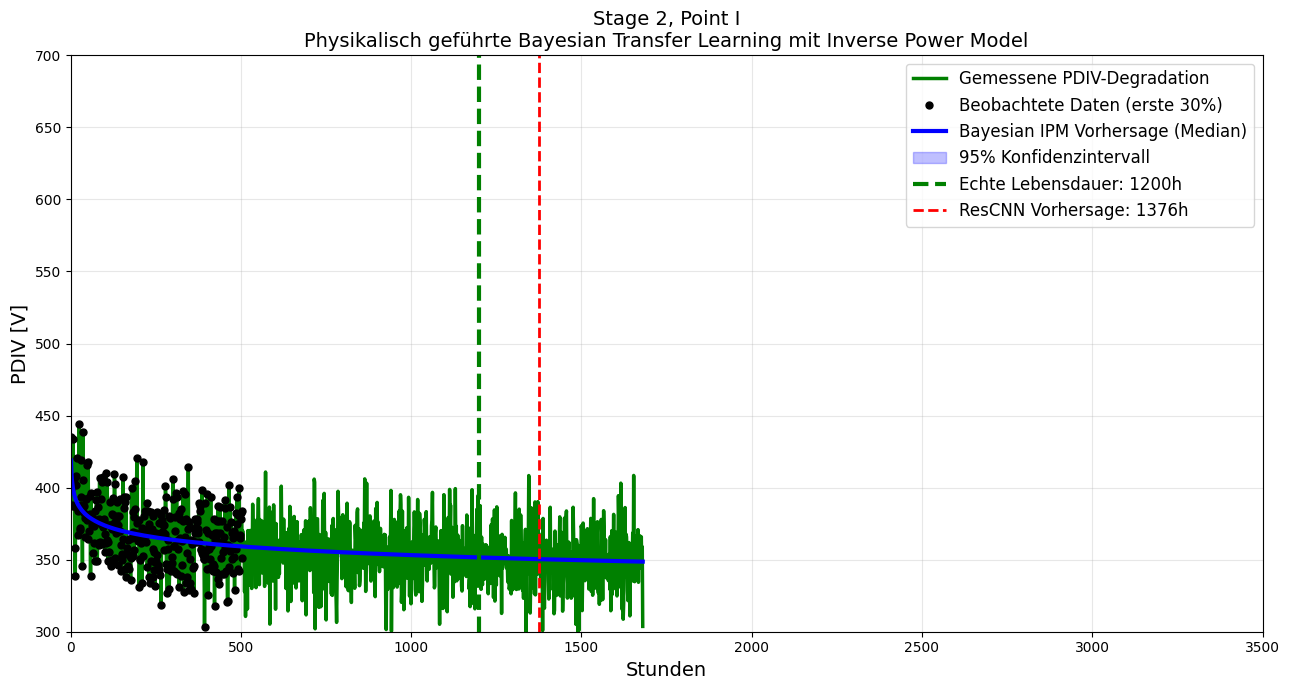

 R² stage 2: 0.9950
 MAE: 0.21 V
Stage 2 für Point II, echte Lebensdauer: 2610h
Accepted 6400 samples, K = 596.2 ± 5.8, n = 0.04480 ± 1.03664


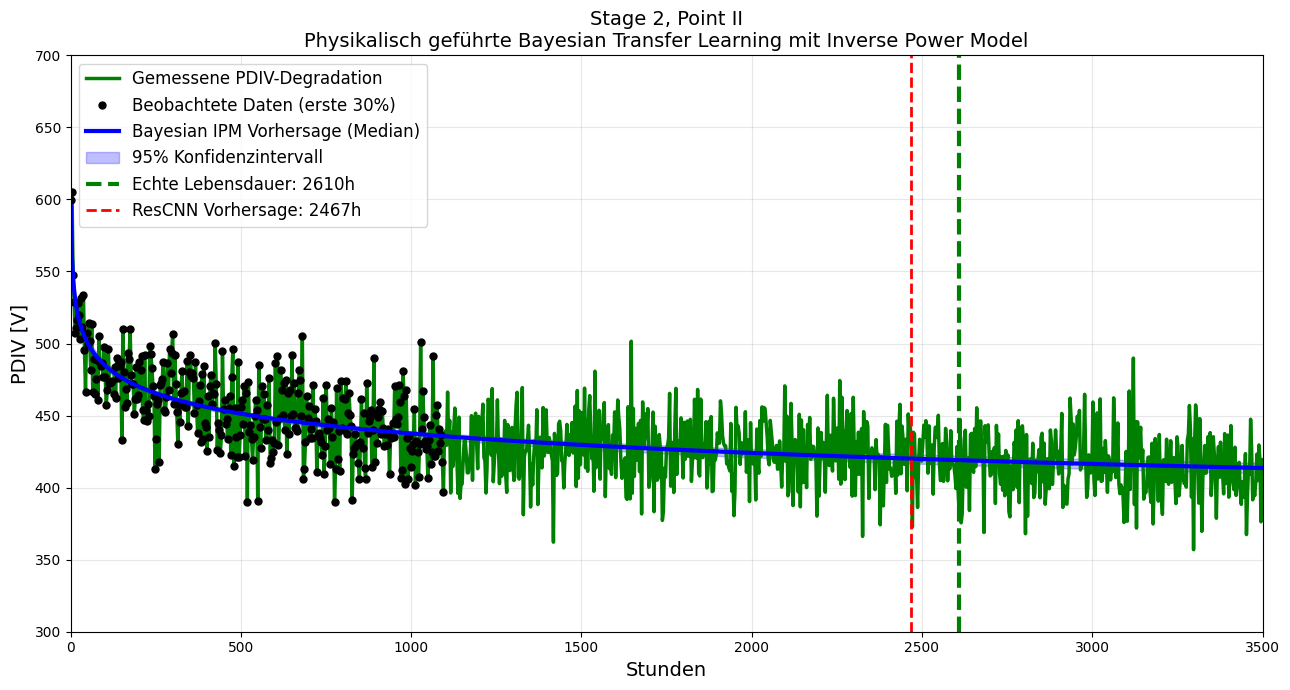

 R² stage 2: 0.9995
 MAE: 0.14 V
Stage 2 für Point III, echte Lebensdauer: 740h
Accepted 6400 samples, K = 469.4 ± 4.2, n = 0.00754 ± 1.29309


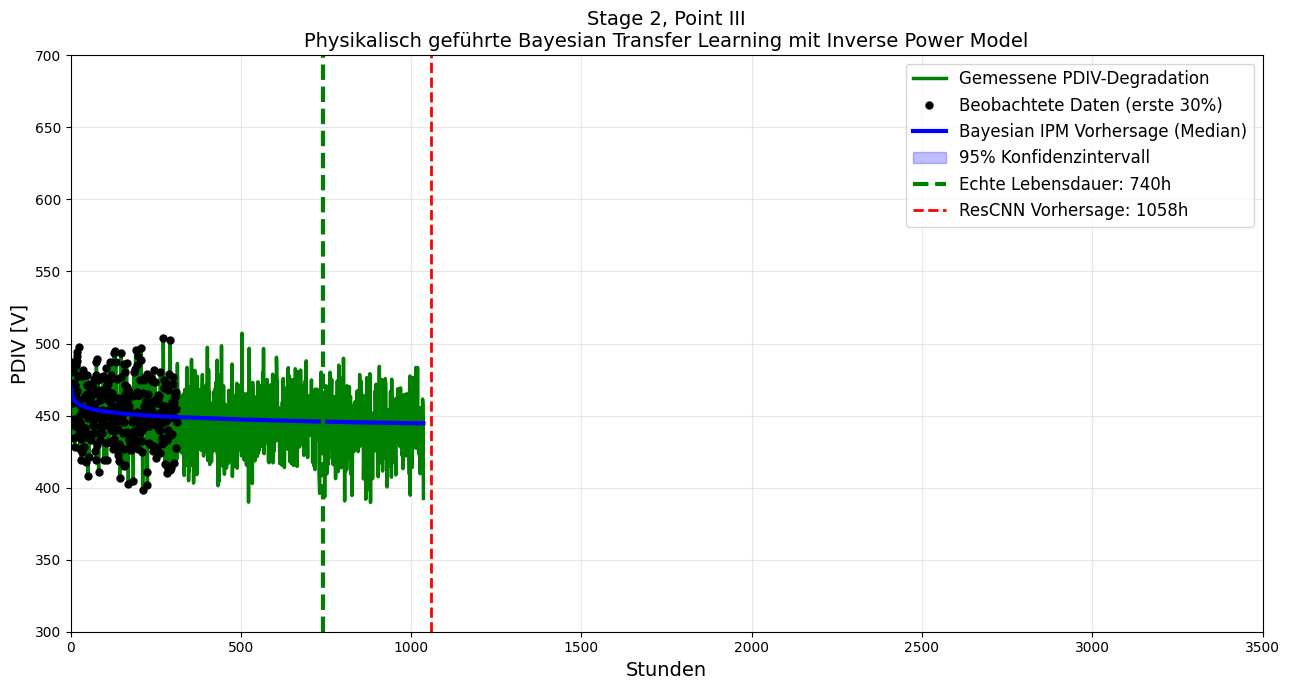

 R² stage 2: 0.9303
 MAE: 0.32 V
Stage 2 für Point IV, echte Lebensdauer: 741h
Accepted 6400 samples, K = 551.2 ± 4.5, n = 0.04747 ± 1.03713


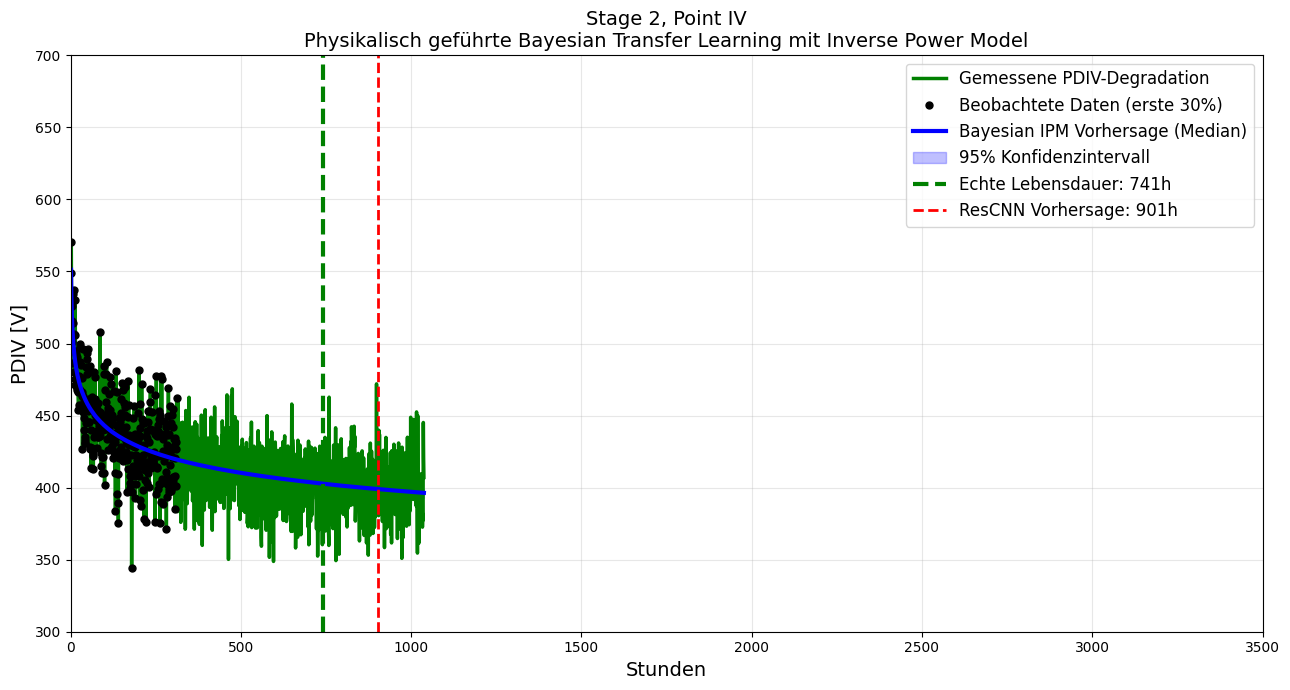

 R² stage 2: 0.9997
 MAE: 0.09 V
Stage 2 für Point V, echte Lebensdauer: 430h
Accepted 6400 samples, K = 527.6 ± 3.9, n = 0.02739 ± 1.06502


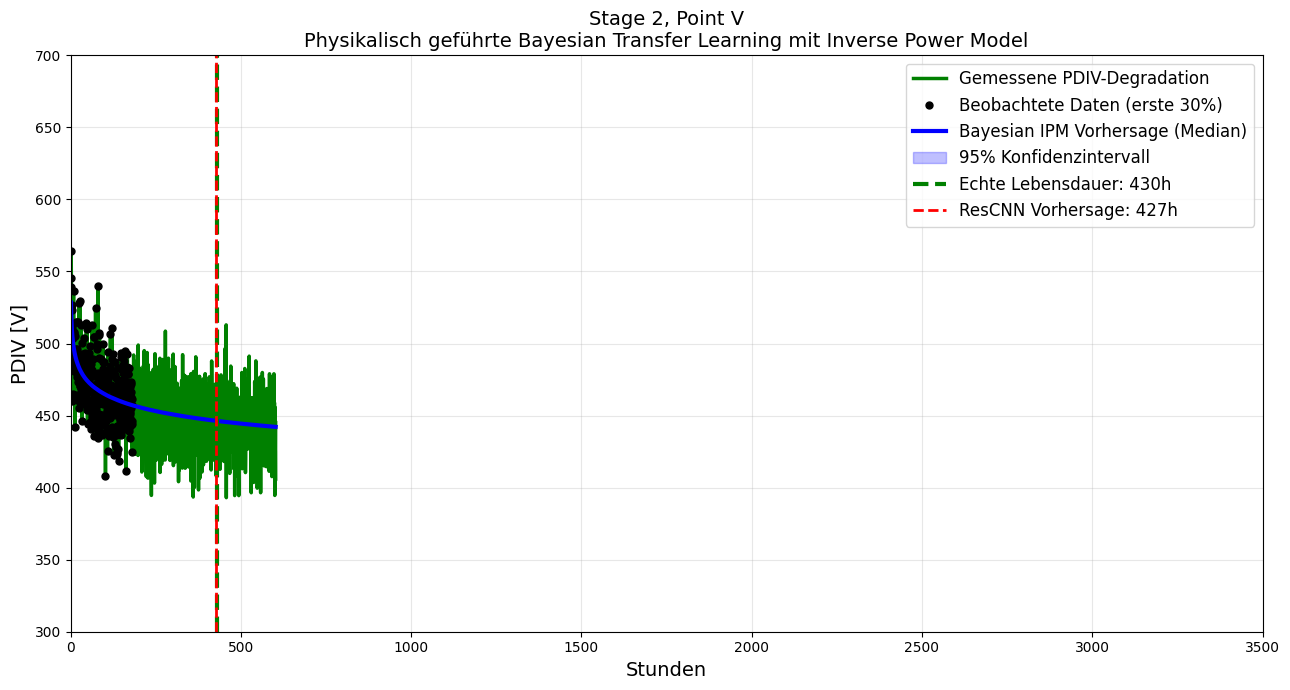

 R² stage 2: 0.9950
 MAE: 0.29 V
Stage 2 für Point VI, echte Lebensdauer: 246h
Accepted 6400 samples, K = 502.8 ± 3.5, n = 0.01866 ± 1.10614


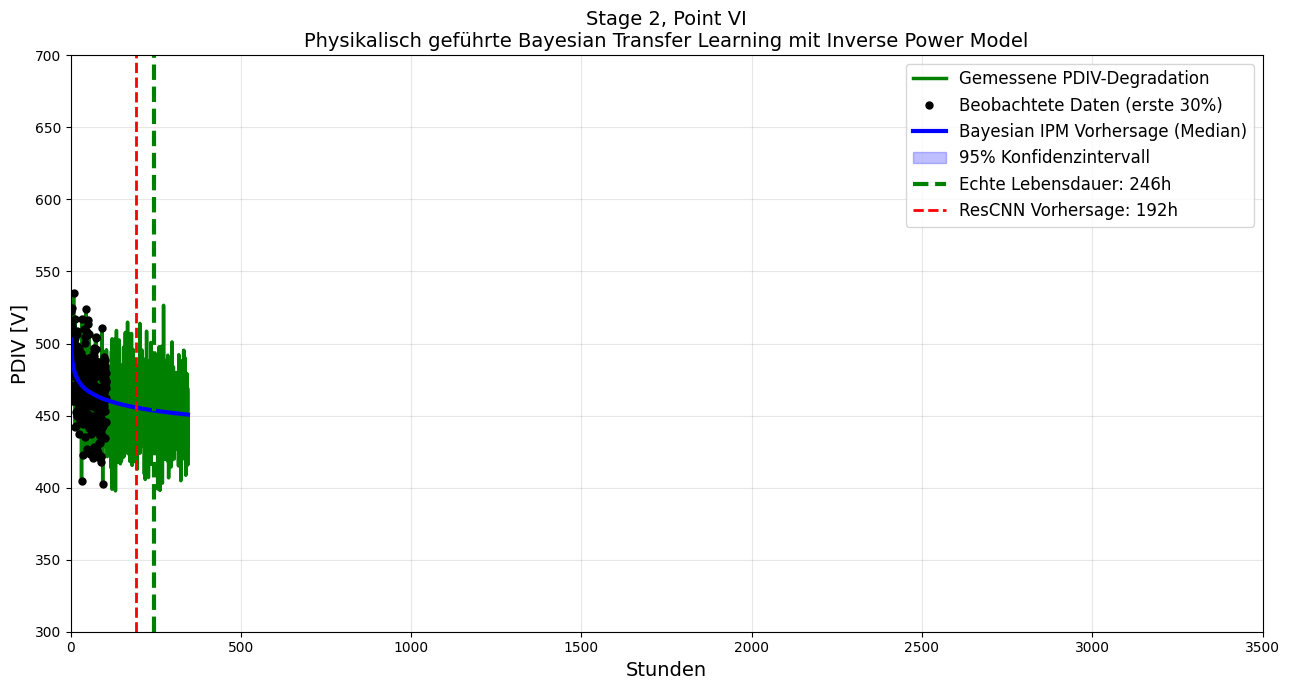

 R² stage 2: 0.9986
 MAE: 0.10 V
Stage 2 für Point VII, echte Lebensdauer: 657h
Accepted 6400 samples, K = 548.8 ± 4.4, n = 0.04762 ± 1.03710


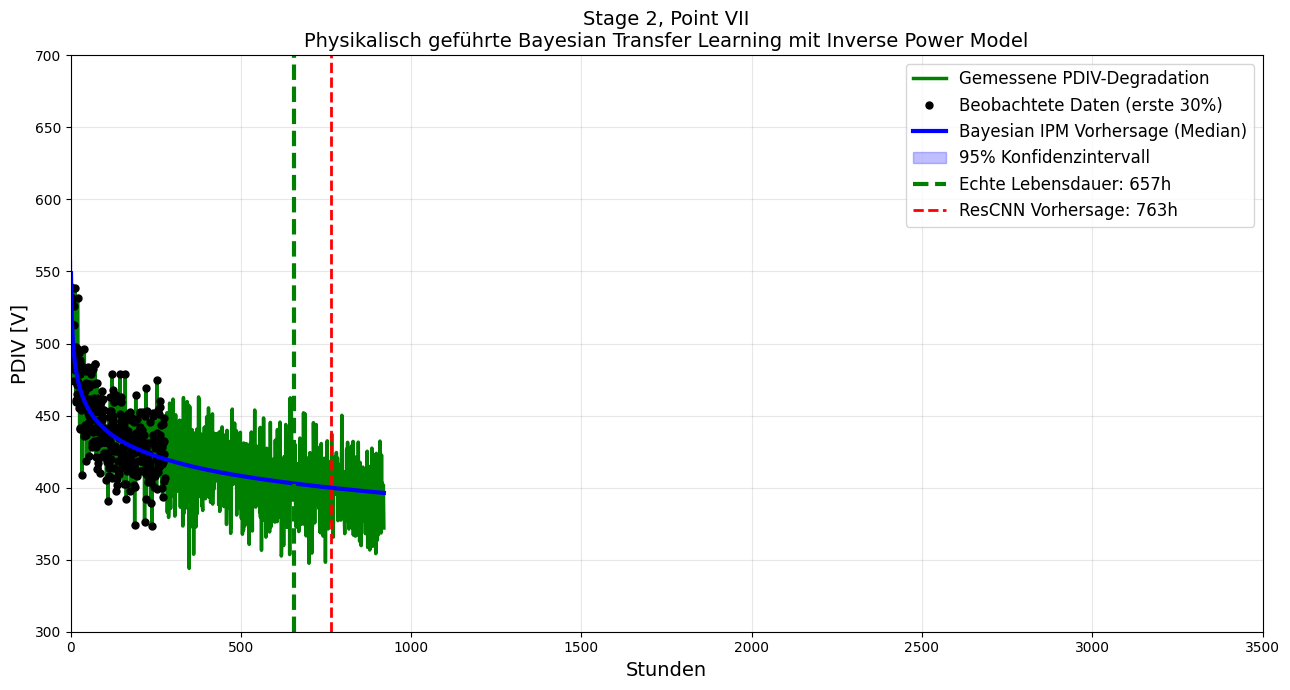

 R² stage 2: 1.0000
 MAE: 0.02 V
Stage 2 für Point VIII, echte Lebensdauer: 1922h
Accepted 6400 samples, K = 559.4 ± 5.3, n = 0.04155 ± 1.04064


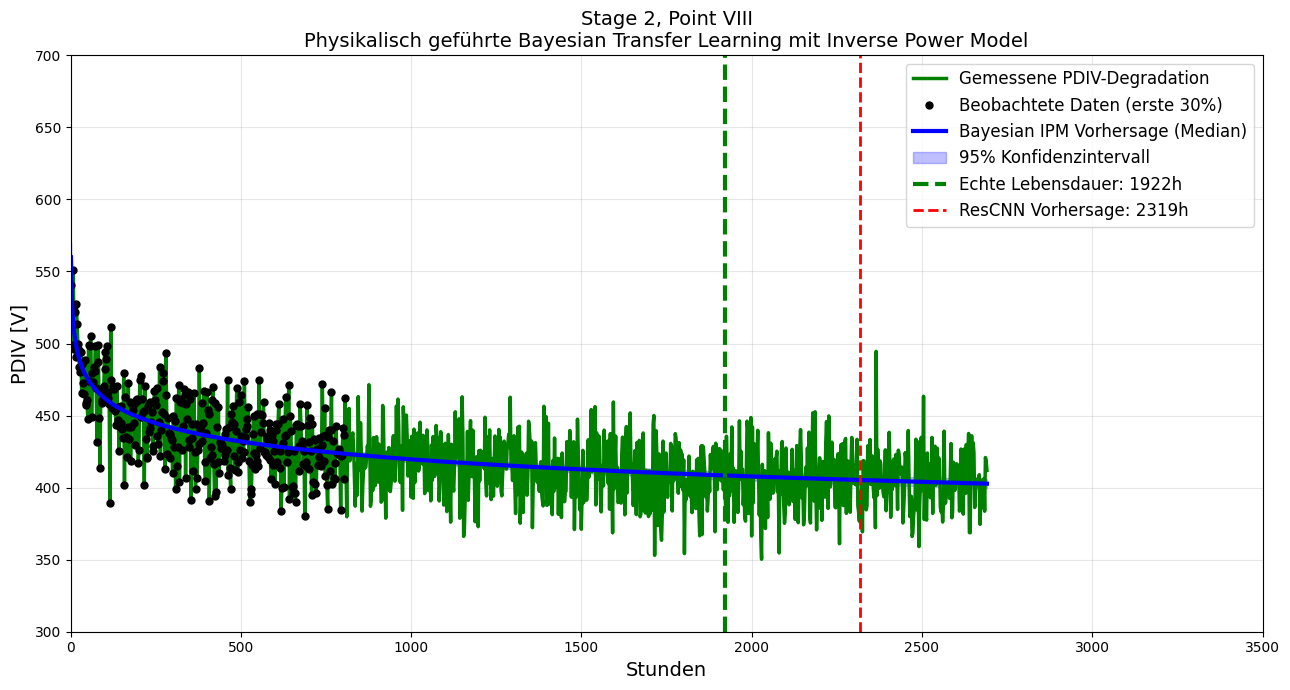

 R² stage 2: 1.0000
 MAE: 0.03 V
Stage 2 für Point IX, echte Lebensdauer: 246h
Accepted 6400 samples, K = 535.7 ± 3.6, n = 0.04785 ± 1.03883


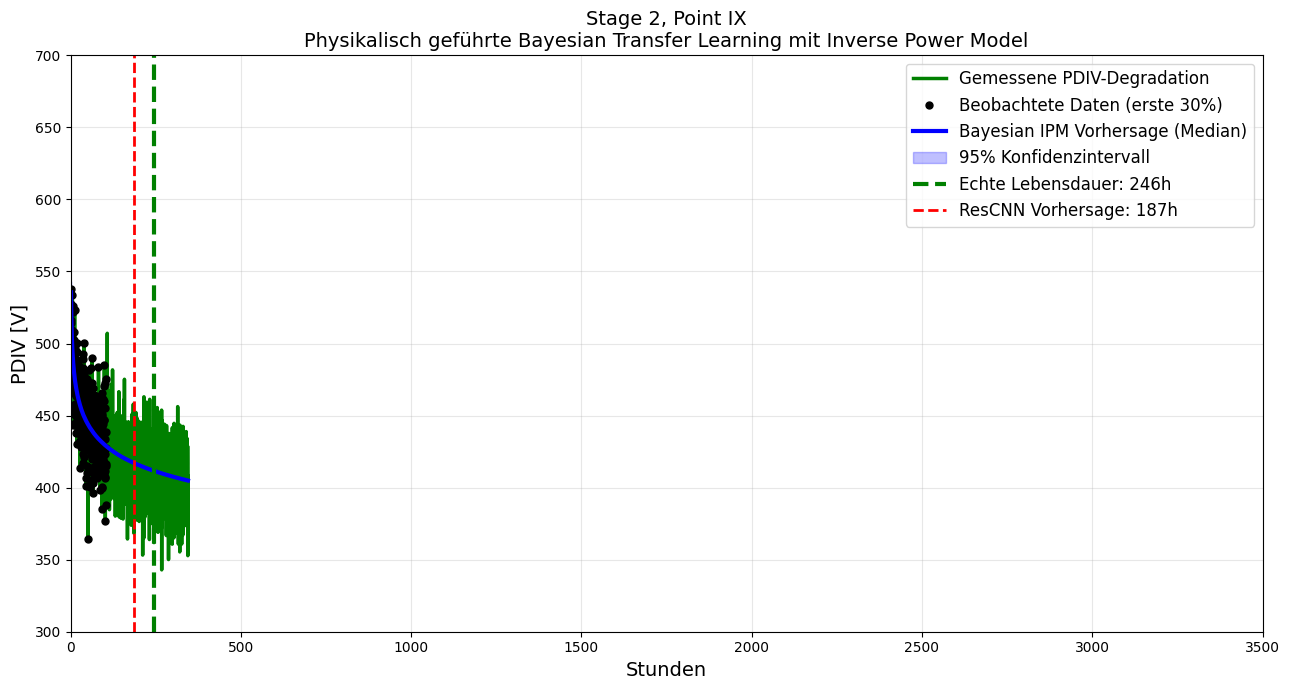

 R² stage 2: 1.0000
 MAE: 0.04 V
Stage 2 für Point X, echte Lebensdauer: 1224h
Accepted 6400 samples, K = 538.5 ± 4.7, n = 0.02970 ± 1.05783


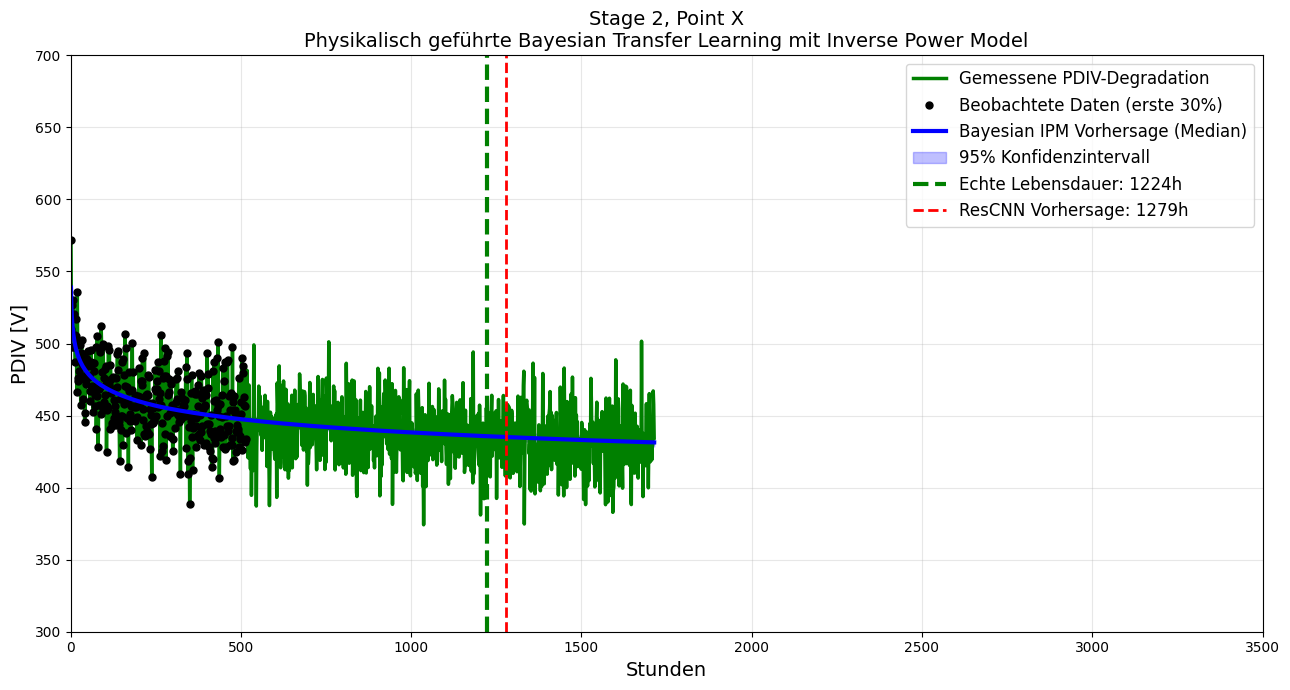

 R² stage 2: 0.9991
 MAE: 0.13 V


In [40]:
#mean_curve_list = [] # Beispiel: Point II (bester Fit in der Dissertation)
for i in range(0,10):
    idx = i #hier ändern, um verschiedene Punkte zu testen (10 Motoren)
    motor = test_data[idx]
    t_full = motor['t']
    pdiv_full = motor['PDIV']
    true_life = motor['lifetime']
    cnn_life = pred_life[idx]

    obs_n = int(0.3 * len(t_full))
    t_obs = t_full[:obs_n]
    pdiv_obs = pdiv_full[:obs_n]

    print(f"Stage 2 für Point {motor['point']}, echte Lebensdauer: {true_life}h")

    # MCMC
    ndim, nwalkers = 2, 64
    # Startwerte in der Nähe des wahren Werts (für schnelle Konvergenz)
    p0 = np.array([580, np.log(0.044)]) + 0.05 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t_obs, pdiv_obs))
    sampler.run_mcmc(p0, 6000, progress=False)
    samples = sampler.get_chain(discard=3000, thin=30, flat=True)

    print(f"Accepted {len(samples)} samples, K = {np.mean(samples[:,0]):.1f} ± {np.std(samples[:,0]):.1f}, "
            f"n = {np.exp(np.mean(samples[:,1])):.5f} ± {np.exp(np.std(samples[:,1])):.5f}")

    # Vorhersage
    n_samples = 150
    curves = []
    for i in np.random.randint(len(samples), size=n_samples):
        K, log_n = samples[i]
        curves.append(ipm_model(t_full, K, np.exp(log_n)))
    curves = np.array(curves)

    mean_curve = np.median(curves, axis=0)  # Median ist robuster als Mean
    lower = np.percentile(curves, 2.5, axis=0)
    upper = np.percentile(curves, 97.5, axis=0)

    #mean_curve_list.append(mean_curve)
    # Plot
    plt.figure(figsize=(13, 7))
    plt.plot(t_full, pdiv_full, 'g-', linewidth=2.5, label='Gemessene PDIV-Degradation')
    plt.plot(t_obs, pdiv_obs, 'ko', markersize=5, label='Beobachtete Daten (erste 30%)')
    plt.plot(t_full, mean_curve, 'b-', linewidth=3, label='Bayesian IPM Vorhersage (Median)')
    plt.fill_between(t_full, lower, upper, color='blue', alpha=0.25, label='95% Konfidenzintervall')
    plt.axvline(true_life, color='green', linestyle='--', linewidth=3, label=f'Echte Lebensdauer: {true_life}h')
    plt.axvline(cnn_life, color='red', linestyle='--', linewidth=2, label=f'ResCNN Vorhersage: {cnn_life:.0f}h')
    plt.xlabel('Stunden', fontsize=14)
    plt.ylabel('PDIV [V]', fontsize=14)
    plt.title(f'Stage 2, Point {motor['point']}\nPhysikalisch geführte Bayesian Transfer Learning mit Inverse Power Model', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 3500)
    plt.ylim(300, 700)
    plt.tight_layout()
    plt.show()



    from scipy.optimize import curve_fit  
    # das IPM direkt auf die beobachteten Daten fitten
    popt, _ = curve_fit(ipm_model, t_obs, pdiv_obs, p0=[600, 0.04], bounds=([300, 0.001], [800, 0.1]))

    # Berechne den wahren Fit 
    true_fit_curve = ipm_model(t_full, *popt)

    #  vergleichen,  (aber nur die geglätteten Kurven)
    r2_s2 = r2_score(true_fit_curve[obs_n:], mean_curve[obs_n:])
    mae_s2 = mean_absolute_error(true_fit_curve[obs_n:], mean_curve[obs_n:])

    print(f" R² stage 2: {r2_s2:.4f}")
    print(f" MAE: {mae_s2:.2f} V")